# Heart Disease Classification with k-NN
**Machine Learning Project — Heart Disease UCI Dataset**

This notebook builds on the structure used in Lab 3 (k-NN on the Wine dataset)
and extends it with:
- preprocessing for a real-world clinical dataset (missing values, categorical
  encoding, feature scaling)
- systematic search over k (extending Exercise 1)
- k-fold cross validation with `StratifiedKFold` (extending Exercise 2, which
  used `ShuffleSplit` with k=2/3 folds)
- comparison of distance metrics (euclidean, manhattan, minkowski)
- a fuller set of evaluation metrics (accuracy, precision, recall, F1,
  confusion matrix) instead of accuracy alone


## 1. Load the dataset

The **Heart Disease UCI** dataset (Cleveland subset, 303 patients, 13
features + target) can be obtained in two ways:

1. **`ucimlrepo`** (if internet access is available):
   ```
   pip install ucimlrepo
   ```
2. **Local CSV**: download `heart.csv` from Kaggle
   ("Heart Disease UCI dataset", e.g. the version by `ronitf` /
   `cherngs`) and place it in the same folder as this notebook.

The cell below tries `ucimlrepo` first and falls back to a local CSV named
`heart.csv` (expected columns: age, sex, cp, trestbps, chol, fbs, restecg,
thalach, exang, oldpeak, slope, ca, thal, target).


In [50]:
import pandas as pd
import numpy as np

COLUMNS = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
           "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

try:
    # Option A: fetch directly from the UCI repository
    from ucimlrepo import fetch_ucirepo
    heart = fetch_ucirepo(id=45)  # Heart Disease (Cleveland)
    X_raw = heart.data.features
    y_raw = heart.data.targets
    df = pd.concat([X_raw, y_raw], axis=1)
    df.columns = COLUMNS
    print("Dataset loaded via ucimlrepo.")
except Exception as e:
    # Option B: load a local CSV (download from Kaggle / UCI beforehand)
    print(f"ucimlrepo not available ({e}). Loading local heart_disease_uci.csv instead.")

    # heart_disease = pd.read_csv("../input/heart-disease-uci/heart.csv")
    df = pd.read_csv("heart_disease_uci.csv")

    if list(df.columns) != COLUMNS and df.shape[1] == len(COLUMNS):
        df.columns = COLUMNS  # align column names if needed

print(df.shape)
df.head()


Dataset loaded via ucimlrepo.
(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [51]:
# from google.colab import files
# uploaded = files.upload()  # apre un file dal computer

## 2. Exploration and pre-processing

Unlike the Wine dataset used in the lab (already clean and on comparable
scales), this dataset needs some pre-processing typical of real clinical
data:
- the target can have values 0–4 (severity); we binarize it to 0 = no
  disease, 1 = disease, as commonly done for this dataset
- some columns (`ca`, `thal`) may contain missing values encoded as `?`
- feature scales are very different (e.g. `age` vs `chol`), which matters a
  lot for a distance-based method like k-NN


In [52]:
# Replace missing-value placeholders and inspect missingness
df = df.replace("?", np.nan)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Missing values per column:")
print(df.isna().sum())

# Binarize the target: 0 = no disease, 1 = disease (any severity 1-4)
df["target"] = (df["target"] > 0).astype(int)
print("\nClass balance:")
print(df["target"].value_counts(normalize=True))


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Class balance:
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [53]:
# Handle missing values: simple median imputation (few missing rows expected)
from sklearn.impute import SimpleImputer

X = df.drop(columns=["target"])
y = df["target"].values

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)


## 3. Train / validation / test split

Same approach as Exercise 1 of the lab: a first split separates the test
set, a second split carves out the validation set from the remaining data.


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (170, 13), Val: (57, 13), Test: (76, 13)


## 4. Feature scaling

k-NN relies on distances between samples, so unscaled features with large
numeric ranges (e.g. `chol`, `trestbps`) would dominate the distance over
binary/small-range features (e.g. `sex`, `fbs`). We fit the scaler on the
training set only, to avoid leaking information from validation/test.


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


## 5. Selecting the best k (extends Exercise 1)

Same logic as the lab exercise: try a range of k values, train on the
training set, evaluate on the validation set, and keep the best one. Here
we extend it by sweeping a wider range of k and plotting the validation
accuracy curve, and by comparing **scaled vs. unscaled** features to show
the impact of scaling on k-NN.


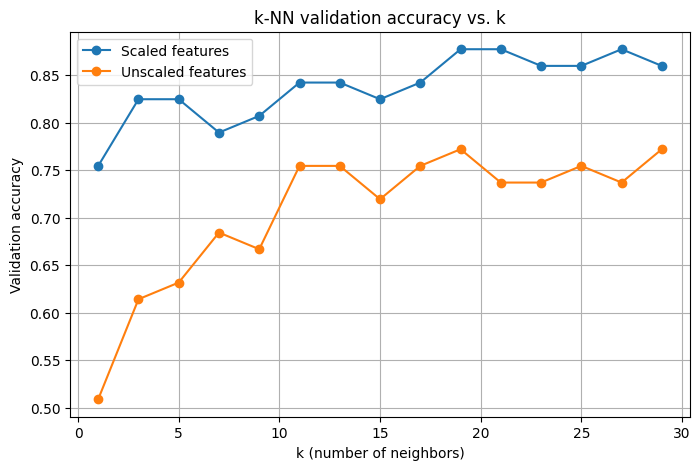

Best k (scaled features): 19
Validation accuracy with the best k: 0.8772


In [56]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

k_values = list(range(1, 31, 2))

def evaluate_k_range(X_tr, y_tr, X_v, y_v, k_values):
    accuracies = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_tr, y_tr)
        accuracies.append(knn.score(X_v, y_v))
    return accuracies

acc_scaled = evaluate_k_range(X_train_scaled, y_train, X_val_scaled, y_val, k_values)
acc_unscaled = evaluate_k_range(X_train, y_train, X_val, y_val, k_values)

plt.figure(figsize=(8, 5))
plt.plot(k_values, acc_scaled, marker="o", label="Scaled features")
plt.plot(k_values, acc_unscaled, marker="o", label="Unscaled features")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Validation accuracy")
plt.title("k-NN validation accuracy vs. k")
plt.legend()
plt.grid(True)
plt.show()

best_k = k_values[int(np.argmax(acc_scaled))]
best_val_accuracy = max(acc_scaled)
print(f"Best k (scaled features): {best_k}")
print(f"Validation accuracy with the best k: {best_val_accuracy:.4f}")


## 6. k-fold cross validation (extends Exercise 2)

Exercise 2 used `ShuffleSplit` with only 2 and 3 folds. Here we use
`StratifiedKFold` (preserves class proportions, important since the dataset
is not perfectly balanced) with a more standard number of folds (5), and we
search jointly over k and distance metric.


In [57]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use the full training+validation portion for cross validation,
# keeping the test set untouched until the final evaluation.
X_trval = np.vstack([X_train_scaled, X_val_scaled])
y_trval = np.concatenate([y_train, y_val])

# Mahalanobis distance requires the (inverse) covariance matrix of the data,
# unlike euclidean/manhattan which need no extra parameters.
cov = np.cov(X_trval, rowvar=False)
inv_cov = np.linalg.inv(cov)

distance_metrics = ["euclidean", "manhattan", "mahalanobis"]

cv_results = []
for metric in distance_metrics:
    metric_params = {"VI": inv_cov} if metric == "mahalanobis" else None
    for k in k_values:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            metric_params=metric_params,
            algorithm="brute",  # required: ball_tree/kd_tree don't support mahalanobis well
        )
        scores = cross_val_score(knn, X_trval, y_trval, cv=cv, scoring="accuracy")
        cv_results.append({"k": k, "metric": metric, "mean_accuracy": scores.mean(),
                            "std_accuracy": scores.std()})

cv_df = pd.DataFrame(cv_results)
best_row = cv_df.loc[cv_df["mean_accuracy"].idxmax()]
print(best_row)

k                         11
metric           mahalanobis
mean_accuracy       0.837391
std_accuracy        0.103223
Name: 35, dtype: object


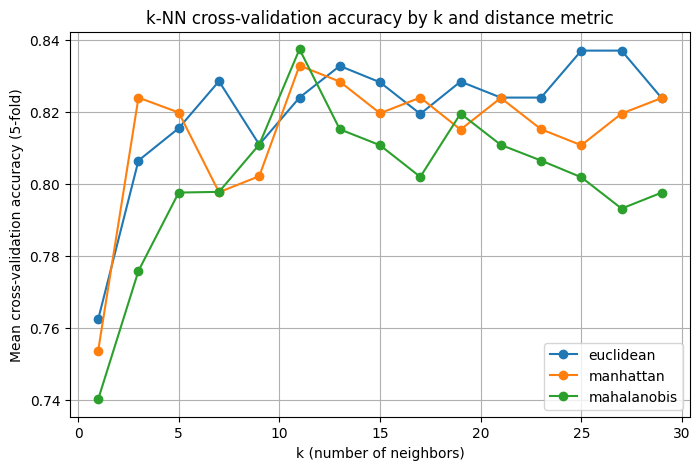

In [58]:
# Visualize cross-validation accuracy by k and distance metric
plt.figure(figsize=(8, 5))
for metric in distance_metrics:
    subset = cv_df[cv_df["metric"] == metric]
    plt.plot(subset["k"], subset["mean_accuracy"], marker="o", label=metric)
plt.xlabel("k (number of neighbors)")
plt.ylabel("Mean cross-validation accuracy (5-fold)")
plt.title("k-NN cross-validation accuracy by k and distance metric")
plt.legend()
plt.grid(True)
plt.show()


## 7. Final model and test set evaluation

We retrain the best configuration (best k + best distance metric, found via
cross validation) on the full training+validation data, and evaluate it
once on the held-out test set — which has not been used so far.


In [59]:
def make_knn(k, metric, inv_cov=None):
    metric_params = {"VI": inv_cov} if metric == "mahalanobis" else None
    return KNeighborsClassifier(
        n_neighbors=k, metric=metric,
        metric_params=metric_params, algorithm="brute",
    )

In [60]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

accuracy = accuracy_score(y_test, pred_test)
precision = precision_score(y_test, pred_test, average="macro")
recall = recall_score(y_test, pred_test, average="macro")
f1 = f1_score(y_test, pred_test, average="macro")

print(f"Best k: {best_k_cv}, distance metric: {best_metric_cv}")
print(f"Test accuracy:  {accuracy:.4f}")
print(f"Test precision: {precision:.4f}")
print(f"Test recall:    {recall:.4f}")
print(f"Test F1-score:  {f1:.4f}")
print()
print(classification_report(y_test, pred_test, target_names=["No disease", "Disease"]))


Best k: 11, distance metric: mahalanobis
Test accuracy:  0.8553
Test precision: 0.8542
Test recall:    0.8554
Test F1-score:  0.8546

              precision    recall  f1-score   support

  No disease       0.88      0.85      0.86        41
     Disease       0.83      0.86      0.85        35

    accuracy                           0.86        76
   macro avg       0.85      0.86      0.85        76
weighted avg       0.86      0.86      0.86        76



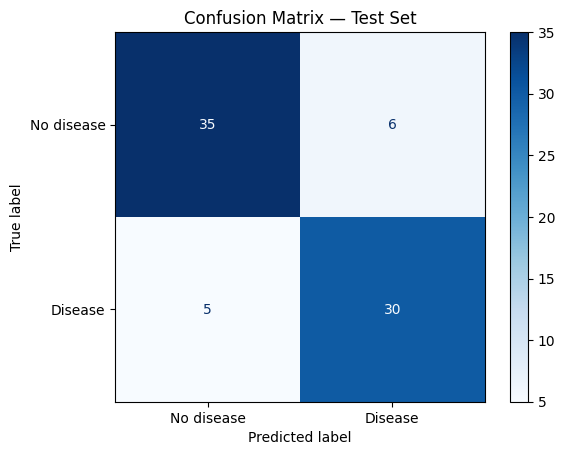

In [61]:
cm = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm, display_labels=["No disease", "Disease"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.show()


## 8. Notes for the report

Points worth discussing in the **Experiments & Results** and **Conclusions**
sections of the report:

- the effect of feature scaling on k-NN performance (compare the two curves
  in Section 5)
- how the best k and best distance metric were chosen via cross validation,
  not on the test set, to avoid overfitting the hyperparameter choice
- discuss any class imbalance and why macro-averaged precision/recall/F1
  are reported in addition to accuracy
- failure cases: look at which patients are misclassified (false negatives
  are particularly important in a clinical context) and discuss possible
  causes (e.g. missing values imputed, overlapping feature distributions
  between classes)
- possible future work: try `KNeighborsClassifier` with weighted voting
  (`weights="distance"`), or compare against another model (e.g. SVM,
  Decision Tree) as a baseline
